In [1]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

In [2]:
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    "ELGnotqso": "ELG",
    "QSO": "QSO",
}

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [3]:
scale_cut = [0.3, 3]
version = "vF"
data_path = (
    f"{ROOT}/results/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_{version}.npz"
)
print(f"Loading from {data_path}...")
data = np.load(data_path)
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]
print(data.files)

Loading from /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/merged_res_norm_0.3_3_vF.npz...
['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


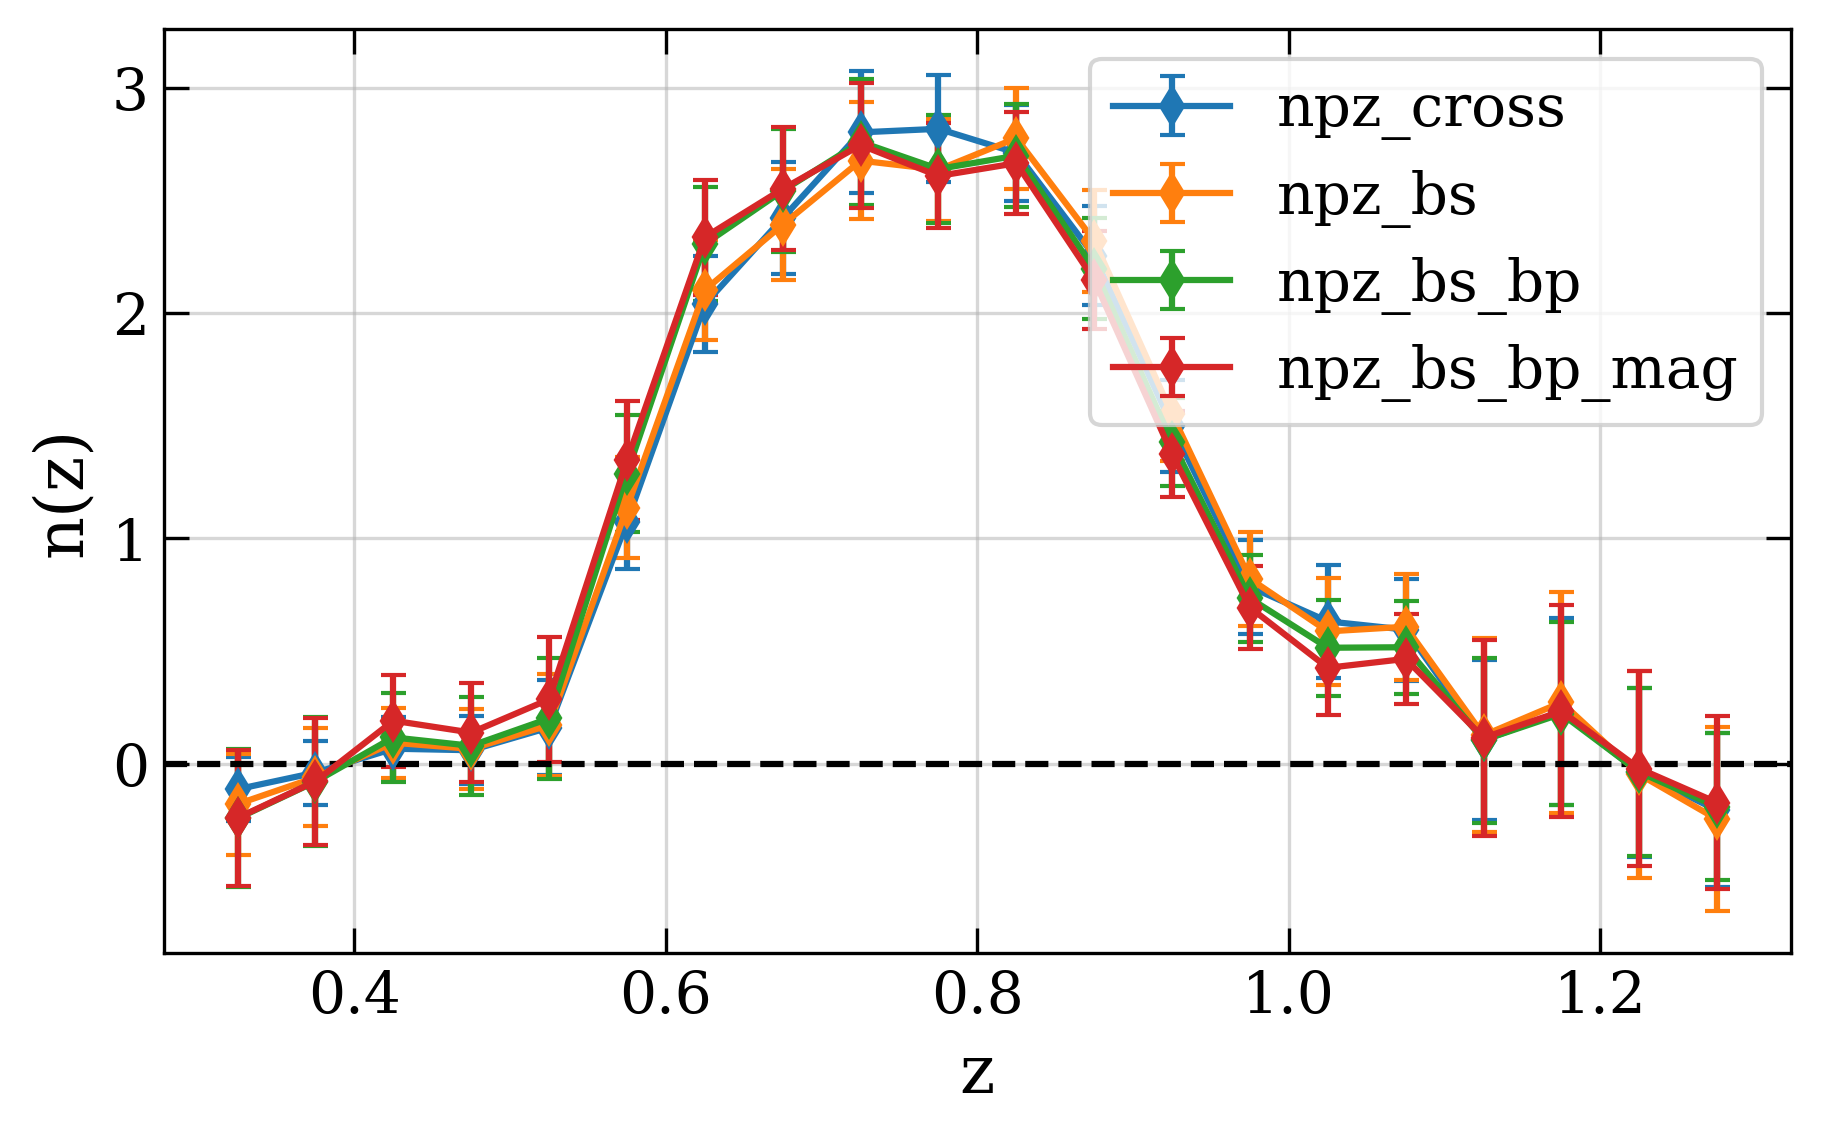

In [4]:
plt.figure(figsize=(7, 4))
tomo = 2
z = [data[f"{tomo}/{name}_z"] for name in names]
npz = [data[f"{tomo}/{name}"] for name in names]
npz_err = [data[f"{tomo}/{name}_err"] for name in names]

for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, marker="d", label=name)
plt.legend(loc="upper right")
plt.grid(True)
plt.ylabel("n(z)")
plt.xlabel("z")
plt.axhline(0, color="black", linestyle="--")

In [5]:
importlib.reload(spline)
for sc in [[0.3, 3], [1, 5]]:  # [1, 5]
    data_file = f"{ROOT}/results/merged_res_norm_{sc[0]}_{sc[1]}_{version}.npz"
    print(f"Processing scale cut {sc}, data file: {data_file}, version: {version}")
    data = np.load(data_file)
    dir_splines = Path(f"{ROOT}/results/splines_{sc[0]}_{sc[1]}_{version}")
    if not dir_splines.exists():
        dir_splines.mkdir(parents=True)
    for i, name in enumerate(names):
        for tomo in range(1, 5):
            savefile = str(dir_splines / f"spl_{name}_{tomo}")
            npz_arr = data[f"{tomo}/{name}"]
            npz_arr_err = data[f"{tomo}/{name}_err"]
            z = data[f"{tomo}/{name}_z"]

            if Path(f"{savefile}.nc").exists():
                print(f"Skipping {savefile}, already exists")
                continue

            spl = spline.BayesianBSpline(zv=z, n_knots=int(len(z) // 2))
            spl.fit(
                npz_arr,
                npz_arr_err,
                n_tune=400,
                n_samples=1600,
                target_accept=0.99,
                prior_concentration=3,
                base_alpha=0.05,
            )
            spl.save_model(savefile)

Processing scale cut [0.3, 3], data file: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/merged_res_norm_0.3_3_vF.npz, version: vF
Dirichlet alpha range: [0.050, 11.960]
Initial amplitude: 9.618
Non-zero NNLS coefficients: 6 / 10
[0.         0.00538742 0.22256351 0.65684618 1.56895138 3.19380279
 3.97010406 0.         0.         0.        ]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 35 seconds.


Model fitting complete. Summary:             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]  0.001  0.003   0.000    0.003      0.000    0.000    1076.0   
coeffs[1]  0.002  0.005   0.000    0.009      0.000    0.000    1025.0   
coeffs[2]  0.020  0.018   0.000    0.053      0.000    0.000    4597.0   
coeffs[3]  0.062  0.024   0.016    0.104      0.000    0.000    7282.0   
coeffs[4]  0.174  0.032   0.111    0.232      0.000    0.000    7016.0   
coeffs[5]  0.330  0.036   0.259    0.395      0.000    0.000    6008.0   
coeffs[6]  0.409  0.030   0.354    0.467      0.000    0.000    6500.0   
coeffs[7]  0.001  0.003   0.000    0.004      0.000    0.000    1073.0   
coeffs[8]  0.001  0.005   0.000    0.005      0.000    0.000     818.0   
coeffs[9]  0.001  0.004   0.000    0.004      0.000    0.000    1547.0   
amplitude  9.323  0.422   8.567   10.154      0.008    0.006    2579.0   

           ess_tail  r_hat  
coeffs[0]     970.0   1.00  
coeffs[1]    1071.0 

...

Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.001  0.006   0.000    0.006      0.000    0.000    1077.0   
coeffs[1]   0.002  0.007   0.000    0.007      0.000    0.000    1259.0   
coeffs[2]   0.001  0.006   0.000    0.006      0.000    0.000    1537.0   
coeffs[3]   0.001  0.005   0.000    0.005      0.000    0.000    1625.0   
coeffs[4]   0.030  0.023   0.000    0.072      0.000    0.000    5838.0   
coeffs[5]   0.001  0.005   0.000    0.005      0.000    0.000    1109.0   
coeffs[6]   0.036  0.023   0.001    0.077      0.000    0.000    6195.0   
coeffs[7]   0.222  0.037   0.155    0.293      0.000    0.000    6384.0   
coeffs[8]   0.288  0.043   0.206    0.367      0.001    0.000    5197.0   
coeffs[9]   0.185  0.038   0.114    0.255      0.000    0.000    6512.0   
coeffs[10]  0.087  0.032   0.027    0.144      0.000    0.000    7327.0   
coeffs[11]  0.027  0.022   0.000    0.067      0.000    0.000    58

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 51 seconds.


Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.003  0.007   0.000    0.016      0.000    0.000    1396.0   
coeffs[1]   0.001  0.004   0.000    0.004      0.000    0.000    1081.0   
coeffs[2]   0.006  0.011   0.000    0.026      0.000    0.000    2381.0   
coeffs[3]   0.005  0.009   0.000    0.021      0.000    0.000    2521.0   
coeffs[4]   0.018  0.017   0.000    0.049      0.000    0.000    4299.0   
coeffs[5]   0.022  0.019   0.000    0.057      0.000    0.000    4979.0   
coeffs[6]   0.246  0.039   0.173    0.321      0.000    0.000    6647.0   
coeffs[7]   0.273  0.045   0.187    0.356      0.001    0.001    6030.0   
coeffs[8]   0.220  0.043   0.143    0.305      0.001    0.000    6763.0   
coeffs[9]   0.136  0.035   0.070    0.200      0.000    0.000    6692.0   
coeffs[10]  0.017  0.019   0.000    0.054      0.000    0.000    3814.0   
coeffs[11]  0.048  0.030   0.002    0.100      0.000    0.000    59